<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/singlecomponent_dyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pure-component dynamic operations with NeqSim

**Audience.** Process engineers, students, and developers learning how equilibrium
thermodynamics and dynamic unit-operation models interact.

**Prerequisites.** Basic Python, pressure–temperature phase behavior, valves,
separators, and material balances.

## Learning objectives

After completing the notebook, you can:

1. build a pure-propane valve–separator–compressor process;
2. switch NeqSim equipment from steady-state to transient calculation;
3. perform pure-component phase-fraction, TP, PH, bubble-point, and dew-point flashes;
4. simulate bounded hydrogen depressurization without evaluating an empty liquid phase;
5. use stream quality specifications; and
6. run a reusable liquid-outlet restriction and active-recovery study.

All pressures are absolute. SI units are used except `bara`, `kg/hr`, and valve
$C_v$, which are retained because these are explicit NeqSim API units and common
process-engineering conventions.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim",
        ],
        check=True,
    )

In [2]:
from importlib.metadata import version

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim import jneqsim
from neqsim.thermo import bubp, bubt, dewp, dewt, fluid, printFrame


NEQSIM_VERSION = version("neqsim")
print(f"NeqSim version: {NEQSIM_VERSION}")

NeqSim version: 3.16.0


## 1. Establish a simple propane process

The original example feeds liquid propane through a throttling valve to a dynamic
separator. Gas is let down and recompressed; liquid leaves through a separate valve.
Every original unit operation remains in the repaired workflow.

For an adiabatic valve with negligible kinetic and potential-energy changes:

$$
h_{in}=h_{out}
$$

The separator inventory follows:

$$
\frac{dM}{dt}
= \dot{m}_{in}-\dot{m}_{gas}-\dot{m}_{liquid}
$$

The SRK equation of state is adequate for this teaching case because the fluids are
pure, non-associating propane or hydrogen. The examples are not equipment designs:
heat transfer, detailed valve characteristics, relief systems, and control-system
dynamics require project-specific models.

In [3]:
propane_feed_fluid = fluid("srk")
propane_feed_fluid.addComponent("propane", 1.0)

propane_feed = jneqsim.process.equipment.stream.Stream(
    "propane feed",
    propane_feed_fluid,
)
propane_feed.setTemperature(278.15, "K")
propane_feed.setPressure(10.0, "bara")
propane_feed.setFlowRate(1000.0, "kg/hr")
propane_feed.run()

feed_valve = jneqsim.process.equipment.valve.ThrottlingValve(
    "propane feed valve",
    propane_feed,
)
feed_valve.setOutletPressure(3.0, "bara")
feed_valve.setPercentValveOpening(50.0)
feed_valve.run()

propane_separator = jneqsim.process.equipment.separator.Separator(
    "propane separator",
    feed_valve.getOutletStream(),
)
propane_separator.setSeparatorLength(2.0)
propane_separator.setInternalDiameter(1.0)
propane_separator.run()

gas_outlet_valve = jneqsim.process.equipment.valve.ThrottlingValve(
    "propane gas outlet valve",
    propane_separator.getGasOutStream(),
)
gas_outlet_valve.setOutletPressure(1.4, "bara")
gas_outlet_valve.setPercentValveOpening(50.0)
gas_outlet_valve.run()

propane_compressor = jneqsim.process.equipment.compressor.Compressor(
    "propane compressor",
    gas_outlet_valve.getOutStream(),
)
propane_compressor.setOutletPressure(5.0, "bara")
propane_compressor.run()

liquid_outlet_valve = jneqsim.process.equipment.valve.ThrottlingValve(
    "propane liquid outlet valve",
    propane_separator.getLiquidOutStream(),
)
liquid_outlet_valve.setOutletPressure(1.4, "bara")
liquid_outlet_valve.setPercentValveOpening(50.0)
liquid_outlet_valve.run()

propane_process = jneqsim.process.processmodel.ProcessSystem(
    "pure propane process",
)
for equipment in [
    feed_valve,
    propane_separator,
    gas_outlet_valve,
    propane_compressor,
    liquid_outlet_valve,
]:
    propane_process.add(equipment)

propane_process.run()

feed_mass_flow_kg_hr = propane_feed.getFlowRate("kg/hr")
gas_mass_flow_kg_hr = propane_separator.getGasOutStream().getFlowRate("kg/hr")
liquid_mass_flow_kg_hr = (
    propane_separator.getLiquidOutStream().getFlowRate("kg/hr")
)
mass_balance_residual = (
    feed_mass_flow_kg_hr
    - gas_mass_flow_kg_hr
    - liquid_mass_flow_kg_hr
)

base_case_table = pd.DataFrame(
    {
        "quantity": [
            "feed pressure",
            "separator pressure",
            "gas outlet flow",
            "liquid outlet flow",
            "compressor outlet pressure",
            "mass-balance residual",
        ],
        "value": [
            propane_feed.getPressure("bara"),
            propane_separator.getPressure("bara"),
            gas_mass_flow_kg_hr,
            liquid_mass_flow_kg_hr,
            propane_compressor.getOutletStream().getPressure("bara"),
            mass_balance_residual,
        ],
        "unit": [
            "bara",
            "bara",
            "kg/hr",
            "kg/hr",
            "bara",
            "kg/hr",
        ],
    }
)
display(base_case_table)

print("Propane feed phase table")
printFrame(propane_feed.getFluid())
print("Fluid immediately downstream of the feed valve")
printFrame(feed_valve.getOutletStream().getFluid())

                     quantity         value   unit
0               feed pressure  1.000000e+01   bara
1          separator pressure  3.000000e+00   bara
2             gas outlet flow  1.223538e+02  kg/hr
3          liquid outlet flow  8.776462e+02  kg/hr
4  compressor outlet pressure  5.000000e+00   bara
5       mass-balance residual  1.136868e-13  kg/hr
Propane feed phase table
                       0           1            2 3 4 5                6
0                              total          OIL                       
1                propane         1E0          1E0        [mole fraction]
2                                                                       
3                Density                5.16411E2                  kg/m3
4         Phase Fraction                      1E0        [mole fraction]
5             Molar Mass   4.4097E-2    4.4097E-2                 kg/mol
6               Z factor               3.69233E-2                    [-]
7     Heat Capacity (Cp)          

In [4]:
valve_table = pd.DataFrame(
    {
        "valve": [
            "feed valve",
            "gas outlet valve",
            "liquid outlet valve",
        ],
        "opening_percent": [
            feed_valve.getPercentValveOpening(),
            gas_outlet_valve.getPercentValveOpening(),
            liquid_outlet_valve.getPercentValveOpening(),
        ],
        "Cv_US": [
            feed_valve.getCv("US"),
            gas_outlet_valve.getCv("US"),
            liquid_outlet_valve.getCv("US"),
        ],
    }
)
display(valve_table)

                 valve  opening_percent     Cv_US
0           feed valve             50.0  1.216022
1     gas outlet valve             50.0  9.010549
2  liquid outlet valve             50.0  2.169473


## 2. Dynamic propane calculation

The source example changes the liquid-outlet valve, then the inlet valve, and finally
restores all openings. Its three original plots are retained below.

NeqSim first solves a steady state. Calling `setCalculateSteadyState(False)` activates
equipment inventory dynamics; `ProcessSystem.runTransient()` advances one configured
time step. The repaired example records actual elapsed time and all state variables at
every step, correcting the prior pressure-array truncation.

In [5]:
for equipment in [
    feed_valve,
    propane_separator,
    gas_outlet_valve,
    liquid_outlet_valve,
]:
    equipment.setCalculateSteadyState(False)

propane_time_step_s = 60.0
propane_process.setTimeStep(propane_time_step_s)

propane_time_s = []
propane_liquid_level = []
propane_temperature_c = []
propane_pressure_bara = []


def record_propane_state(step_number):
    propane_time_s.append(step_number * propane_time_step_s)
    propane_liquid_level.append(propane_separator.getLiquidLevel())
    propane_temperature_c.append(
        propane_separator.getFluid().getTemperature("C")
    )
    propane_pressure_bara.append(
        propane_separator.getFluid().getPressure("bara")
    )


step_number = 0
for _ in range(10):
    propane_process.runTransient()
    step_number += 1
    record_propane_state(step_number)

liquid_outlet_valve.setPercentValveOpening(20.0)
for _ in range(10):
    propane_process.runTransient()
    step_number += 1
    record_propane_state(step_number)

feed_valve.setPercentValveOpening(10.0)
for _ in range(10):
    propane_process.runTransient()
    step_number += 1
    record_propane_state(step_number)

feed_valve.setPercentValveOpening(50.0)
liquid_outlet_valve.setPercentValveOpening(50.0)
gas_outlet_valve.setPercentValveOpening(50.0)
for _ in range(50):
    propane_process.runTransient()
    step_number += 1
    record_propane_state(step_number)

propane_time_min = np.asarray(propane_time_s) / 60.0
propane_transient_table = pd.DataFrame(
    {
        "time_min": propane_time_min,
        "liquid_level_fraction": propane_liquid_level,
        "separator_temperature_degC": propane_temperature_c,
        "separator_pressure_bara": propane_pressure_bara,
    }
)
display(propane_transient_table.iloc[[0, 9, 19, 29, -1]])

    time_min  ...  separator_pressure_bara
0        1.0  ...                      3.0
9       10.0  ...                      3.0
19      20.0  ...                      3.0
29      30.0  ...                      3.0
79      80.0  ...                      3.0

[5 rows x 4 columns]


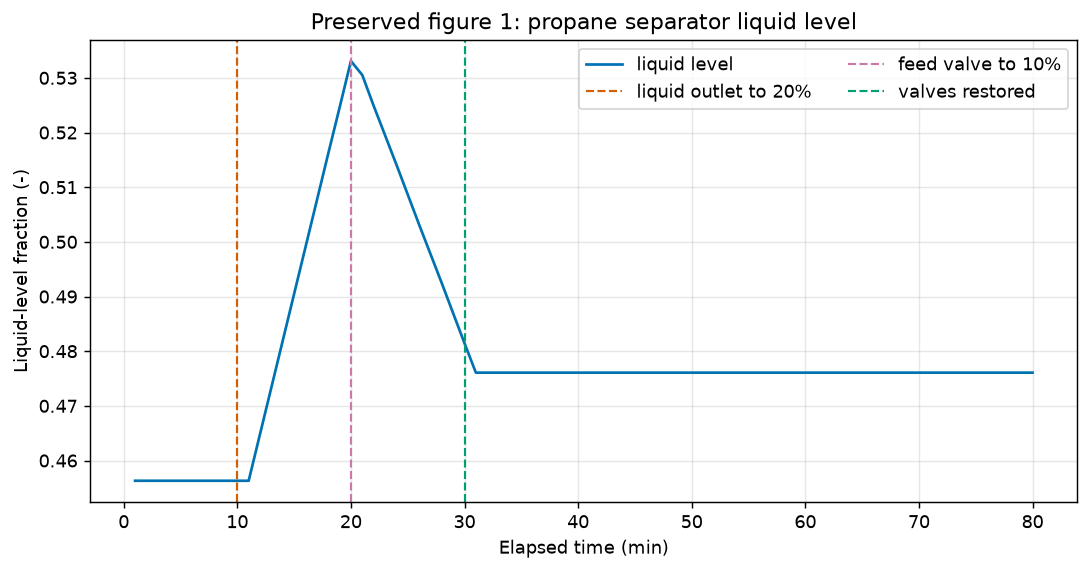

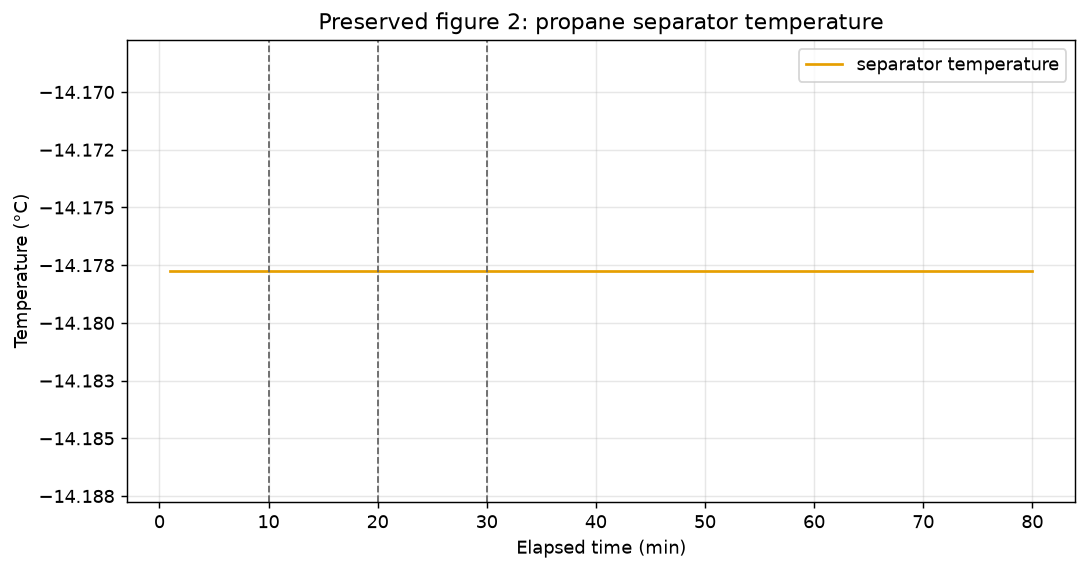

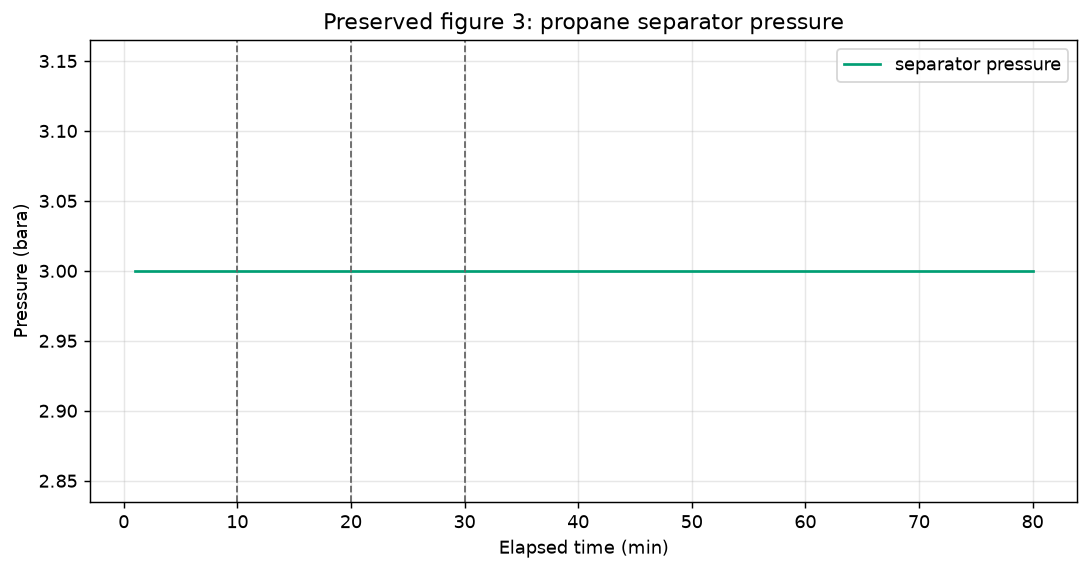

In [6]:
event_times_min = [10.0, 20.0, 30.0]
event_labels = [
    "liquid outlet to 20%",
    "feed valve to 10%",
    "valves restored",
]
event_colors = ["#D55E00", "#CC79A7", "#009E73"]

plt.figure(figsize=(8.5, 4.5))
plt.plot(
    propane_time_min,
    propane_liquid_level,
    color="#0072B2",
    label="liquid level",
)
for event_time, event_label, event_color in zip(
    event_times_min,
    event_labels,
    event_colors,
):
    plt.axvline(
        event_time,
        color=event_color,
        linestyle="--",
        linewidth=1.2,
        label=event_label,
    )
plt.xlabel("Elapsed time (min)")
plt.ylabel("Liquid-level fraction (-)")
plt.title("Preserved figure 1: propane separator liquid level")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 4.5))
plt.plot(
    propane_time_min,
    propane_temperature_c,
    color="#E69F00",
    label="separator temperature",
)
for event_time in event_times_min:
    plt.axvline(event_time, color="#666666", linestyle="--", linewidth=1.0)
plt.xlabel("Elapsed time (min)")
plt.ylabel("Temperature (°C)")
plt.title("Preserved figure 2: propane separator temperature")
mean_propane_temperature_c = np.mean(propane_temperature_c)
plt.ylim(
    mean_propane_temperature_c - 0.01,
    mean_propane_temperature_c + 0.01,
)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.3f}"))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 4.5))
plt.plot(
    propane_time_min,
    propane_pressure_bara,
    color="#009E73",
    label="separator pressure",
)
for event_time in event_times_min:
    plt.axvline(event_time, color="#666666", linestyle="--", linewidth=1.0)
plt.xlabel("Elapsed time (min)")
plt.ylabel("Pressure (bara)")
plt.title("Preserved figure 3: propane separator pressure")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Single-component flash routines

For a pure component, liquid and vapor coexist on the saturation line. The vapor
fraction is:

$$
\beta = \frac{n_v}{n_v+n_l}
$$

`constantPhaseFractionPressureFlash(0.5)` finds the pressure for equal vapor and
liquid amounts at fixed temperature. The corresponding temperature flash finds the
saturation temperature at fixed pressure. For a pure component, all intermediate
phase fractions identify the same saturation state.

### 3.1 Phase-fraction pressure and temperature flashes

This cell preserves the original equal-phase-fraction example while storing the two
results in an auditable table.

In [7]:
phase_fraction_fluid = fluid("srk")
phase_fraction_fluid.addComponent("propane", 1.0)
phase_fraction_fluid.setTemperature(-20.0, "C")
phase_fraction_fluid.setPressure(10.0, "bara")

phase_fraction_flash = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations(
        phase_fraction_fluid
    )
)
phase_fraction_flash.TPflash()
phase_fraction_flash.constantPhaseFractionPressureFlash(0.5)
saturation_pressure_bara = phase_fraction_fluid.getPressure("bara")

phase_fraction_flash.constantPhaseFractionTemperatureFlash(0.5)
saturation_temperature_c = phase_fraction_fluid.getTemperature("C")

phase_fraction_table = pd.DataFrame(
    {
        "calculation": [
            "50% phase-fraction pressure flash",
            "50% phase-fraction temperature flash",
        ],
        "value": [
            saturation_pressure_bara,
            saturation_temperature_c,
        ],
        "unit": [
            "bara",
            "°C",
        ],
    }
)
display(phase_fraction_table)
printFrame(phase_fraction_fluid)

                            calculation      value  unit
0     50% phase-fraction pressure flash   2.440451  bara
1  50% phase-fraction temperature flash -20.000000    °C
                       0           1                   2  ... 4 5                6
0                              total                 GAS  ...                     
1                propane         1E0                 1E0  ...      [mole fraction]
2                                                         ...                     
3                Density                       5.45543E0  ...                kg/m3
4         Phase Fraction                            5E-1  ...      [mole fraction]
5             Molar Mass   4.4097E-2           4.4097E-2  ...               kg/mol
6               Z factor                      9.37213E-1  ...                  [-]
7     Heat Capacity (Cp)                       1.53066E0  ...               kJ/kgK
8     Heat Capacity (Cv)                        1.2958E0  ...               kJ/kgK

### 3.2 TP, PH, and saturation calculations

A TP flash establishes equilibrium at specified temperature and pressure. A PH flash
then finds the temperature after changing pressure while holding enthalpy constant,
which represents the ideal throttling relation used earlier. `dewt` evaluates the
pure-propane saturation temperature at the resulting pressure.

In [8]:
enthalpy_fluid = fluid("srk")
enthalpy_fluid.addComponent("propane", 1.0)
enthalpy_fluid.setTemperature(278.15, "K")
enthalpy_fluid.setPressure(10.0, "bara")

enthalpy_flash = jneqsim.thermodynamicoperations.ThermodynamicOperations(
    enthalpy_fluid
)
enthalpy_flash.TPflash()
enthalpy_fluid.initProperties()

initial_enthalpy_j = enthalpy_fluid.getEnthalpy()
initial_internal_energy_j = enthalpy_fluid.getInternalEnergy()
initial_volume_m3 = enthalpy_fluid.getVolume()

enthalpy_fluid.setPressure(3.0, "bara")
enthalpy_flash.PHflash(initial_enthalpy_j)
ph_flash_temperature_c = enthalpy_fluid.getTemperature("C")
ph_flash_enthalpy_j = enthalpy_fluid.getEnthalpy()

dewt(enthalpy_fluid)
dew_point_temperature_c = enthalpy_fluid.getTemperature("C")

flash_audit_table = pd.DataFrame(
    {
        "quantity": [
            "initial enthalpy",
            "initial internal energy",
            "initial volume",
            "PH-flash temperature at 3 bara",
            "PH-flash enthalpy residual",
            "pure-propane dew temperature at 3 bara",
        ],
        "value": [
            initial_enthalpy_j,
            initial_internal_energy_j,
            initial_volume_m3,
            ph_flash_temperature_c,
            ph_flash_enthalpy_j - initial_enthalpy_j,
            dew_point_temperature_c,
        ],
        "unit": [
            "J",
            "J",
            "m³",
            "°C",
            "J",
            "°C",
        ],
    }
)
display(flash_audit_table)
printFrame(enthalpy_fluid)

                                 quantity         value unit
0                        initial enthalpy -16884.717263    J
1                 initial internal energy -16975.188603    J
2                          initial volume      9.047134   m³
3          PH-flash temperature at 3 bara    -14.177747   °C
4              PH-flash enthalpy residual      0.000000    J
5  pure-propane dew temperature at 3 bara    -14.177747   °C
                       0           1                    2  ... 4 5                6
0                              total                  GAS  ...                     
1                propane         1E0                  1E0  ...      [mole fraction]
2                                                          ...                     
3                Density                        6.62924E0  ...                kg/m3
4         Phase Fraction                              1E0  ...      [mole fraction]
5             Molar Mass   4.4097E-2            4.4097E-2  ...       

## 4. Hydrogen depressurization

The original example feeds hydrogen to a separator and nearly closes the inlet valve.
Hydrogen remains single phase, so its nominal liquid outlet has zero mass flow. The
previous notebook attempted to format that empty phase in `J/kg`, causing an arithmetic
exception with current NeqSim. The repaired cell reports zero flow without requesting
undefined mass-specific properties.

The transient is also stopped before the vessel crosses the 1.01325 bara downstream
boundary. A real system would need a vacuum breaker, non-return logic, heat transfer,
and a relief/depressurization study.

In [9]:
hydrogen_feed_fluid = fluid("srk")
hydrogen_feed_fluid.addComponent("hydrogen", 1.0)

hydrogen_feed = jneqsim.process.equipment.stream.Stream(
    "hydrogen feed",
    hydrogen_feed_fluid,
)
hydrogen_feed.setTemperature(278.15, "K")
hydrogen_feed.setPressure(10.0, "bara")
hydrogen_feed.setFlowRate(100.0, "kg/hr")
hydrogen_feed.run()

hydrogen_feed_valve = jneqsim.process.equipment.valve.ThrottlingValve(
    "hydrogen feed valve",
    hydrogen_feed,
)
hydrogen_feed_valve.setOutletPressure(3.0, "bara")
hydrogen_feed_valve.run()

hydrogen_separator = jneqsim.process.equipment.separator.Separator(
    "hydrogen separator",
    hydrogen_feed_valve.getOutletStream(),
)
hydrogen_separator.setSeparatorLength(4.0)
hydrogen_separator.setInternalDiameter(2.0)
hydrogen_separator.setLiquidLevel(0.000001)
hydrogen_separator.run()

hydrogen_gas_valve = jneqsim.process.equipment.valve.ThrottlingValve(
    "hydrogen gas valve",
    hydrogen_separator.getGasOutStream(),
)
hydrogen_gas_valve.setOutletPressure(1.01325, "bara")
hydrogen_gas_valve.run()

hydrogen_compressor = jneqsim.process.equipment.compressor.Compressor(
    "hydrogen compressor",
    hydrogen_gas_valve.getOutStream(),
)
hydrogen_compressor.setOutletPressure(5.0, "bara")
hydrogen_compressor.run()

hydrogen_liquid_valve = jneqsim.process.equipment.valve.ThrottlingValve(
    "hydrogen nominal liquid valve",
    hydrogen_separator.getLiquidOutStream(),
)
hydrogen_liquid_valve.setOutletPressure(1.01325, "bara")
hydrogen_liquid_valve.run()

hydrogen_process = jneqsim.process.processmodel.ProcessSystem(
    "hydrogen depressurization process",
)
for equipment in [
    hydrogen_feed_valve,
    hydrogen_separator,
    hydrogen_gas_valve,
    hydrogen_compressor,
    hydrogen_liquid_valve,
]:
    hydrogen_process.add(equipment)

hydrogen_process.run()

for equipment in [
    hydrogen_feed_valve,
    hydrogen_separator,
    hydrogen_gas_valve,
    hydrogen_liquid_valve,
]:
    equipment.setCalculateSteadyState(False)

hydrogen_time_step_s = 1.0
hydrogen_process.setTimeStep(hydrogen_time_step_s)

hydrogen_time_s = []
hydrogen_flow_kg_hr = []
hydrogen_liquid_level = []
hydrogen_temperature_c = []
hydrogen_pressure_bara = []


def record_hydrogen_state(step_number):
    hydrogen_time_s.append(step_number * hydrogen_time_step_s)
    hydrogen_flow_kg_hr.append(
        hydrogen_gas_valve.getOutletStream().getFlowRate("kg/hr")
    )
    hydrogen_liquid_level.append(hydrogen_separator.getLiquidLevel())
    hydrogen_temperature_c.append(
        hydrogen_separator.getFluid().getTemperature("C")
    )
    hydrogen_pressure_bara.append(
        hydrogen_separator.getFluid().getPressure("bara")
    )


hydrogen_step_number = 0
for _ in range(50):
    hydrogen_process.runTransient()
    hydrogen_step_number += 1
    record_hydrogen_state(hydrogen_step_number)

hydrogen_feed_valve.setPercentValveOpening(0.1)
for _ in range(200):
    hydrogen_process.runTransient()
    hydrogen_step_number += 1
    record_hydrogen_state(hydrogen_step_number)
    if hydrogen_pressure_bara[-1] <= 1.05:
        break

hydrogen_time_min = np.asarray(hydrogen_time_s) / 60.0
hydrogen_summary = pd.DataFrame(
    {
        "quantity": [
            "simulated duration",
            "initial vessel pressure",
            "final vessel pressure",
            "final gas outlet flow",
            "nominal liquid outlet flow",
        ],
        "value": [
            hydrogen_time_s[-1],
            hydrogen_pressure_bara[0],
            hydrogen_pressure_bara[-1],
            hydrogen_flow_kg_hr[-1],
            hydrogen_liquid_valve.getOutletStream().getFlowRate("kg/hr"),
        ],
        "unit": [
            "s",
            "bara",
            "bara",
            "kg/hr",
            "kg/hr",
        ],
    }
)
display(hydrogen_summary)

                     quantity       value   unit
0          simulated duration  145.000000      s
1     initial vessel pressure    3.000000   bara
2       final vessel pressure    1.049560   bara
3       final gas outlet flow   28.161396  kg/hr
4  nominal liquid outlet flow    0.000000  kg/hr


In [10]:
hydrogen_valve_table = pd.DataFrame(
    {
        "valve": [
            "hydrogen feed valve",
            "hydrogen gas outlet valve",
        ],
        "Cv_US": [
            hydrogen_feed_valve.getCv("US"),
            hydrogen_gas_valve.getCv("US"),
        ],
    }
)
display(hydrogen_valve_table)

                       valve      Cv_US
0        hydrogen feed valve   5.016329
1  hydrogen gas outlet valve  16.679664


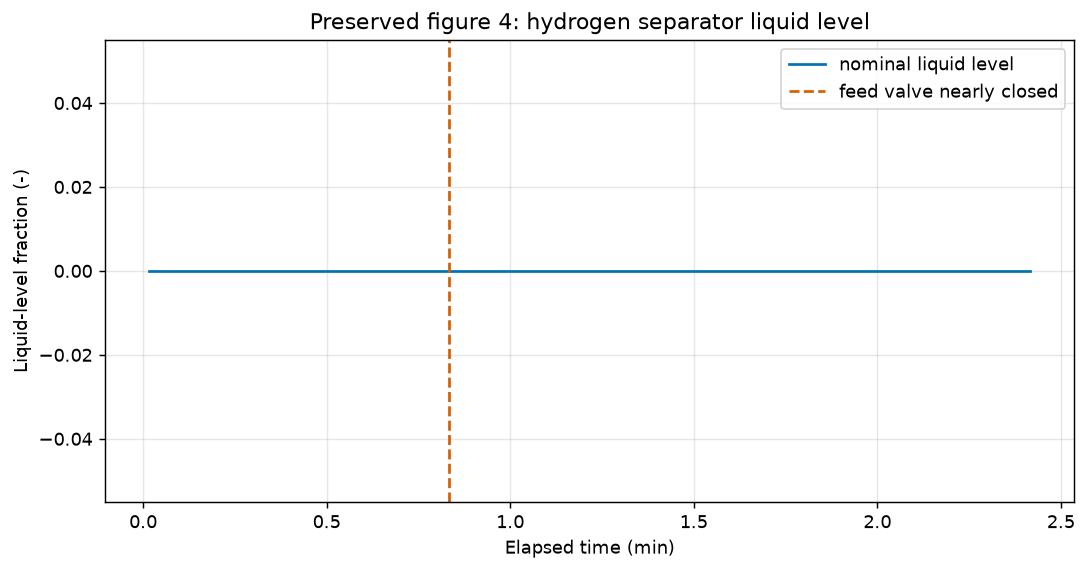

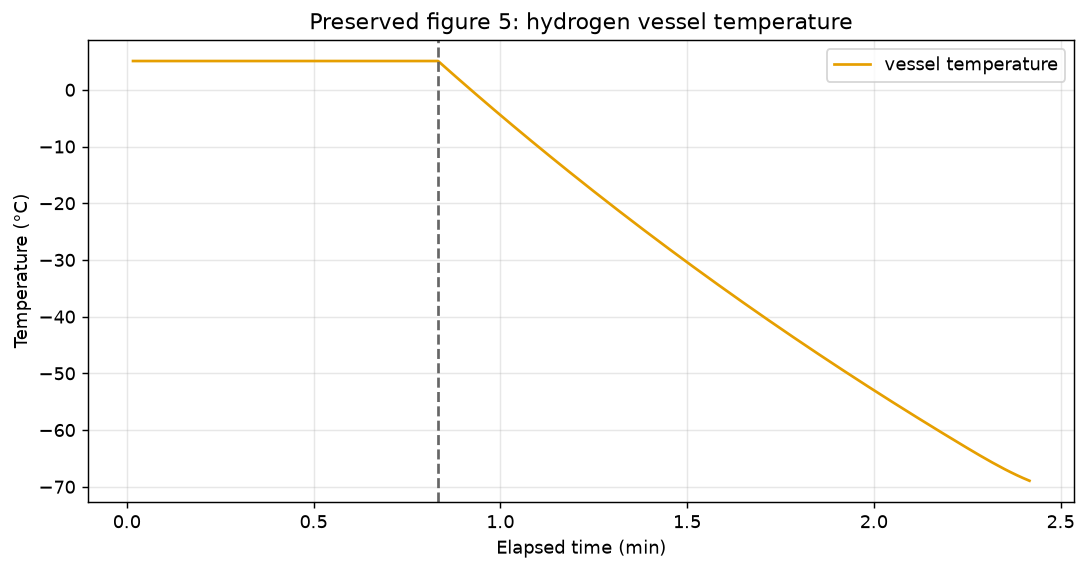

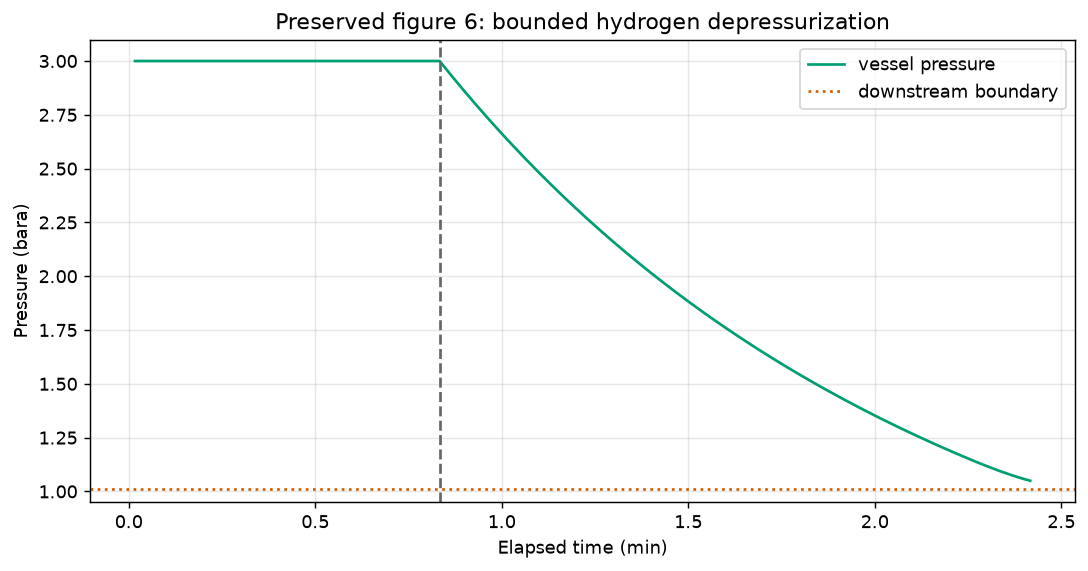

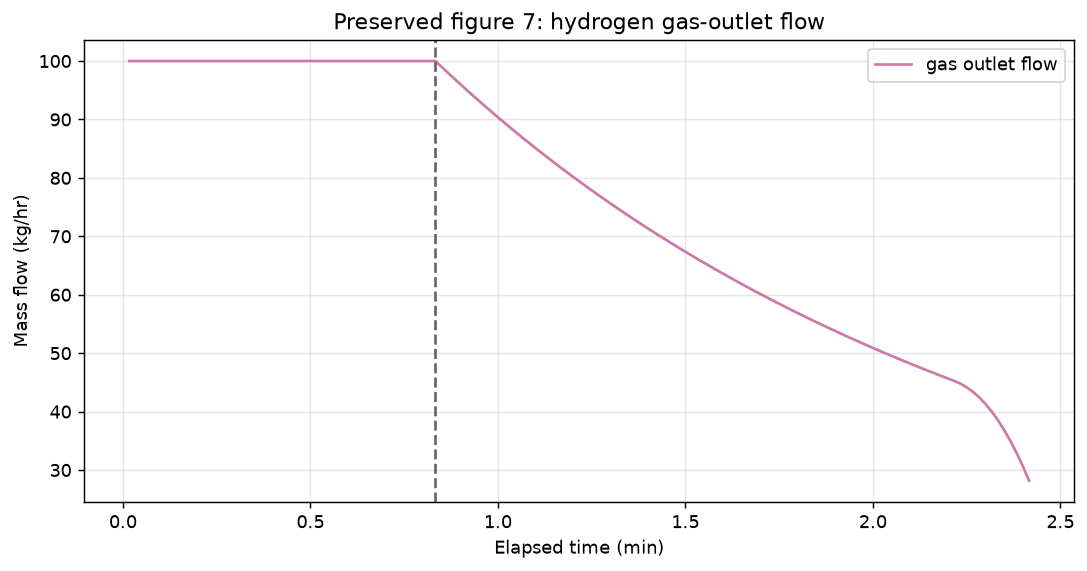

In [11]:
hydrogen_event_min = 50.0 / 60.0

plt.figure(figsize=(8.5, 4.5))
plt.plot(
    hydrogen_time_min,
    hydrogen_liquid_level,
    color="#0072B2",
    label="nominal liquid level",
)
plt.axvline(
    hydrogen_event_min,
    color="#D55E00",
    linestyle="--",
    label="feed valve nearly closed",
)
plt.xlabel("Elapsed time (min)")
plt.ylabel("Liquid-level fraction (-)")
plt.title("Preserved figure 4: hydrogen separator liquid level")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 4.5))
plt.plot(
    hydrogen_time_min,
    hydrogen_temperature_c,
    color="#E69F00",
    label="vessel temperature",
)
plt.axvline(hydrogen_event_min, color="#666666", linestyle="--")
plt.xlabel("Elapsed time (min)")
plt.ylabel("Temperature (°C)")
plt.title("Preserved figure 5: hydrogen vessel temperature")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 4.5))
plt.plot(
    hydrogen_time_min,
    hydrogen_pressure_bara,
    color="#009E73",
    label="vessel pressure",
)
plt.axhline(
    1.01325,
    color="#D55E00",
    linestyle=":",
    label="downstream boundary",
)
plt.axvline(hydrogen_event_min, color="#666666", linestyle="--")
plt.xlabel("Elapsed time (min)")
plt.ylabel("Pressure (bara)")
plt.title("Preserved figure 6: bounded hydrogen depressurization")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 4.5))
plt.plot(
    hydrogen_time_min,
    hydrogen_flow_kg_hr,
    color="#CC79A7",
    label="gas outlet flow",
)
plt.axvline(hydrogen_event_min, color="#666666", linestyle="--")
plt.xlabel("Elapsed time (min)")
plt.ylabel("Mass flow (kg/hr)")
plt.title("Preserved figure 7: hydrogen gas-outlet flow")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Stream-quality specifications

The original final cell demonstrates three stream specifications:

- `gas quality` imposes a requested vapor fraction;
- `bubP` finds bubble-point pressure at the stream temperature; and
- `dewP` finds dew-point pressure at the stream temperature.

For a pure component, bubble and dew pressure coincide at a specified temperature.
Independent fluid objects avoid hidden state between the three calculations.

In [12]:
quality_gas_fluid = fluid("srk")
quality_gas_fluid.addComponent("propane", 1.0)
quality_gas_stream = jneqsim.process.equipment.stream.Stream(
    "propane gas-quality stream",
    quality_gas_fluid,
)
quality_gas_stream.setSpecification("gas quality")
quality_gas_stream.setPressure(10.0, "bara")
quality_gas_stream.setGasQuality(0.1)
quality_gas_stream.setFlowRate(1000.0, "kg/hr")
quality_gas_stream.run()

bubble_fluid = fluid("srk")
bubble_fluid.addComponent("propane", 1.0)
bubble_stream = jneqsim.process.equipment.stream.Stream(
    "propane bubble-pressure stream",
    bubble_fluid,
)
bubble_stream.setSpecification("bubP")
bubble_stream.setPressure(1.0, "bara")
bubble_stream.setFlowRate(1000.0, "kg/hr")
bubble_stream.run()

dew_fluid = fluid("srk")
dew_fluid.addComponent("propane", 1.0)
dew_stream = jneqsim.process.equipment.stream.Stream(
    "propane dew-pressure stream",
    dew_fluid,
)
dew_stream.setSpecification("dewP")
dew_stream.setPressure(5.0, "bara")
dew_stream.setFlowRate(1000.0, "kg/hr")
dew_stream.run()

quality_specification_table = pd.DataFrame(
    {
        "specification": [
            "gas quality",
            "bubble pressure",
            "dew pressure",
        ],
        "temperature_degC": [
            quality_gas_stream.getTemperature("C"),
            bubble_stream.getTemperature("C"),
            dew_stream.getTemperature("C"),
        ],
        "pressure_bara": [
            quality_gas_stream.getPressure("bara"),
            bubble_stream.getPressure("bara"),
            dew_stream.getPressure("bara"),
        ],
        "vapor_fraction": [
            quality_gas_stream.getFluid().getBeta(),
            bubble_stream.getFluid().getBeta(),
            dew_stream.getFluid().getBeta(),
        ],
    }
)
display(quality_specification_table)

     specification  temperature_degC  pressure_bara  vapor_fraction
0      gas quality         26.500068           10.0    1.000000e-01
1  bubble pressure        -42.177721            1.0    1.000000e-10
2     dew pressure          1.563643            5.0    1.000000e+00


## 6. Preservation checklist and repairs

All 20 source cells remain represented in their original order and all four source
workflows execute:

1. propane steady and transient process;
2. pure-component flash and saturation routines;
3. hydrogen depressurization; and
4. stream-quality specifications.

All seven original plots are recalculated above. Repairs include the Colab path,
single conditional installation, current Java runtime usage, readable Python,
complete time arrays, phase-safe empty-outlet handling, a pressure-boundary stop,
explicit units, deterministic tables, and nearby engineering interpretation.

## 7. Final application: liquid-outlet operability study

The final application turns the source process into a reusable engineering workflow.
Three fresh NeqSim process models are built to avoid hidden state. Each case runs:

1. ten minutes at 50% liquid-valve opening;
2. twenty minutes at a case-specific restriction; and
3. twenty minutes at a temporary 75% recovery opening.

The practical question is whether separator liquid inventory remains bounded and
can be reduced with an active outlet-opening response after a restriction. Returning
only to the original 50% opening balances the nominal inflow and does not drain the
accumulated inventory, so the recovery action temporarily opens the valve to 75%.
This is an operability screen, not a certified level-control or relief-system design.

In [13]:
def build_propane_separator_model(case_name):
    case_fluid = fluid("srk")
    case_fluid.addComponent("propane", 1.0)

    case_feed = jneqsim.process.equipment.stream.Stream(
        f"{case_name} feed",
        case_fluid,
    )
    case_feed.setTemperature(278.15, "K")
    case_feed.setPressure(10.0, "bara")
    case_feed.setFlowRate(1000.0, "kg/hr")
    case_feed.run()

    case_feed_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        f"{case_name} feed valve",
        case_feed,
    )
    case_feed_valve.setOutletPressure(3.0, "bara")
    case_feed_valve.setPercentValveOpening(50.0)
    case_feed_valve.run()

    case_separator = jneqsim.process.equipment.separator.Separator(
        f"{case_name} separator",
        case_feed_valve.getOutletStream(),
    )
    case_separator.setSeparatorLength(2.0)
    case_separator.setInternalDiameter(1.0)
    case_separator.run()

    case_gas_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        f"{case_name} gas valve",
        case_separator.getGasOutStream(),
    )
    case_gas_valve.setOutletPressure(1.4, "bara")
    case_gas_valve.setPercentValveOpening(50.0)
    case_gas_valve.run()

    case_liquid_valve = jneqsim.process.equipment.valve.ThrottlingValve(
        f"{case_name} liquid valve",
        case_separator.getLiquidOutStream(),
    )
    case_liquid_valve.setOutletPressure(1.4, "bara")
    case_liquid_valve.setPercentValveOpening(50.0)
    case_liquid_valve.run()

    case_process = jneqsim.process.processmodel.ProcessSystem(case_name)
    for case_equipment in [
        case_feed_valve,
        case_separator,
        case_gas_valve,
        case_liquid_valve,
    ]:
        case_process.add(case_equipment)

    case_process.run()
    for case_equipment in [
        case_feed_valve,
        case_separator,
        case_gas_valve,
        case_liquid_valve,
    ]:
        case_equipment.setCalculateSteadyState(False)

    case_process.setTimeStep(60.0)
    return {
        "process": case_process,
        "separator": case_separator,
        "liquid_valve": case_liquid_valve,
    }


def run_liquid_valve_scenario(restricted_opening_percent):
    case_name = f"propane restriction {restricted_opening_percent:.0f}"
    model = build_propane_separator_model(case_name)
    case_process = model["process"]
    case_separator = model["separator"]
    case_liquid_valve = model["liquid_valve"]

    records = []
    for step_number in range(50):
        if step_number == 10:
            case_liquid_valve.setPercentValveOpening(
                restricted_opening_percent
            )
        if step_number == 30:
            case_liquid_valve.setPercentValveOpening(75.0)

        case_process.runTransient()
        records.append(
            {
                "time_min": step_number + 1,
                "restricted_opening_percent": (
                    restricted_opening_percent
                ),
                "liquid_level_fraction": case_separator.getLiquidLevel(),
                "pressure_bara": case_separator.getPressure("bara"),
                "temperature_degC": case_separator.getTemperature("C"),
            }
        )

    return pd.DataFrame(records)

In [14]:
scenario_frames = [
    run_liquid_valve_scenario(opening)
    for opening in [15.0, 30.0, 45.0]
]
scenario_results = pd.concat(scenario_frames, ignore_index=True)

scenario_summary = (
    scenario_results.groupby(
        "restricted_opening_percent",
        as_index=False,
    )
    .agg(
        maximum_level_fraction=("liquid_level_fraction", "max"),
        final_level_fraction=("liquid_level_fraction", "last"),
        maximum_pressure_bara=("pressure_bara", "max"),
        minimum_temperature_degC=("temperature_degC", "min"),
    )
    .sort_values("restricted_opening_percent")
)
display(scenario_summary)

   restricted_opening_percent  ...  minimum_temperature_degC
0                        15.0  ...                -14.177747
1                        30.0  ...                -14.177747
2                        45.0  ...                -14.177747

[3 rows x 5 columns]


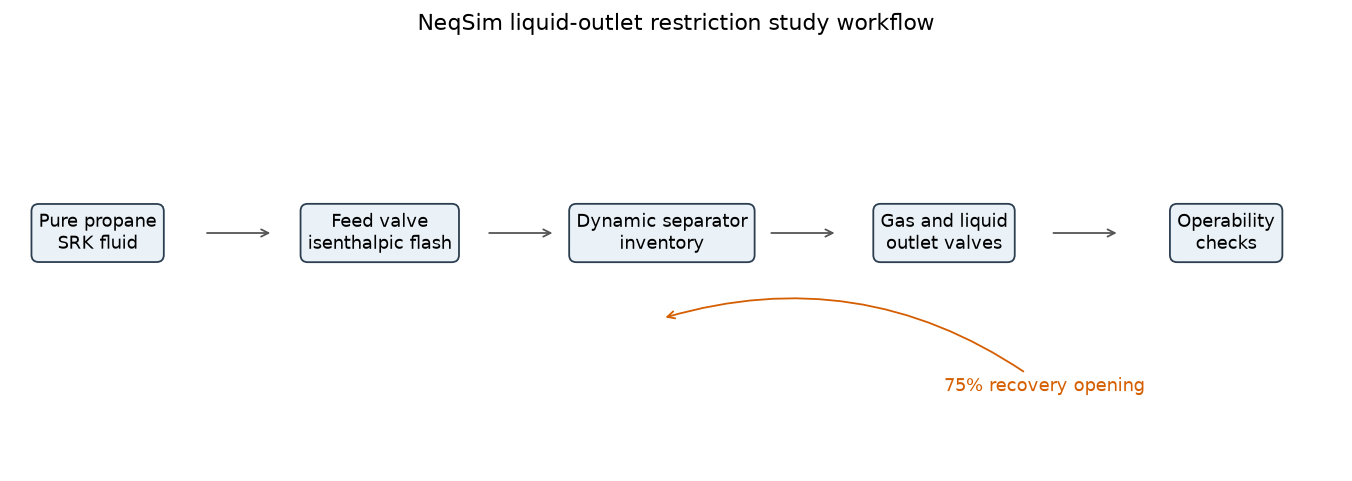

In [15]:
figure, axis = plt.subplots(figsize=(10.5, 3.8))
box_style = {
    "boxstyle": "round,pad=0.4",
    "facecolor": "#EAF2F8",
    "edgecolor": "#2C3E50",
}
stages = [
    (0.06, "Pure propane\nSRK fluid"),
    (0.26, "Feed valve\nisenthalpic flash"),
    (0.46, "Dynamic separator\ninventory"),
    (0.66, "Gas and liquid\noutlet valves"),
    (0.86, "Operability\nchecks"),
]
for x_position, label in stages:
    axis.text(
        x_position,
        0.55,
        label,
        ha="center",
        va="center",
        bbox=box_style,
    )
for start, end in zip(stages[:-1], stages[1:]):
    axis.annotate(
        "",
        xy=(end[0] - 0.075, 0.55),
        xytext=(start[0] + 0.075, 0.55),
        arrowprops={"arrowstyle": "->", "color": "#555555"},
    )
axis.annotate(
    "75% recovery opening",
    xy=(0.46, 0.35),
    xytext=(0.66, 0.18),
    arrowprops={
        "arrowstyle": "->",
        "connectionstyle": "arc3,rad=0.25",
        "color": "#D55E00",
    },
    color="#D55E00",
)
axis.set_title("NeqSim liquid-outlet restriction study workflow")
axis.set_xlim(0.0, 0.94)
axis.set_ylim(0.0, 1.0)
axis.axis("off")
figure.tight_layout()
plt.show()

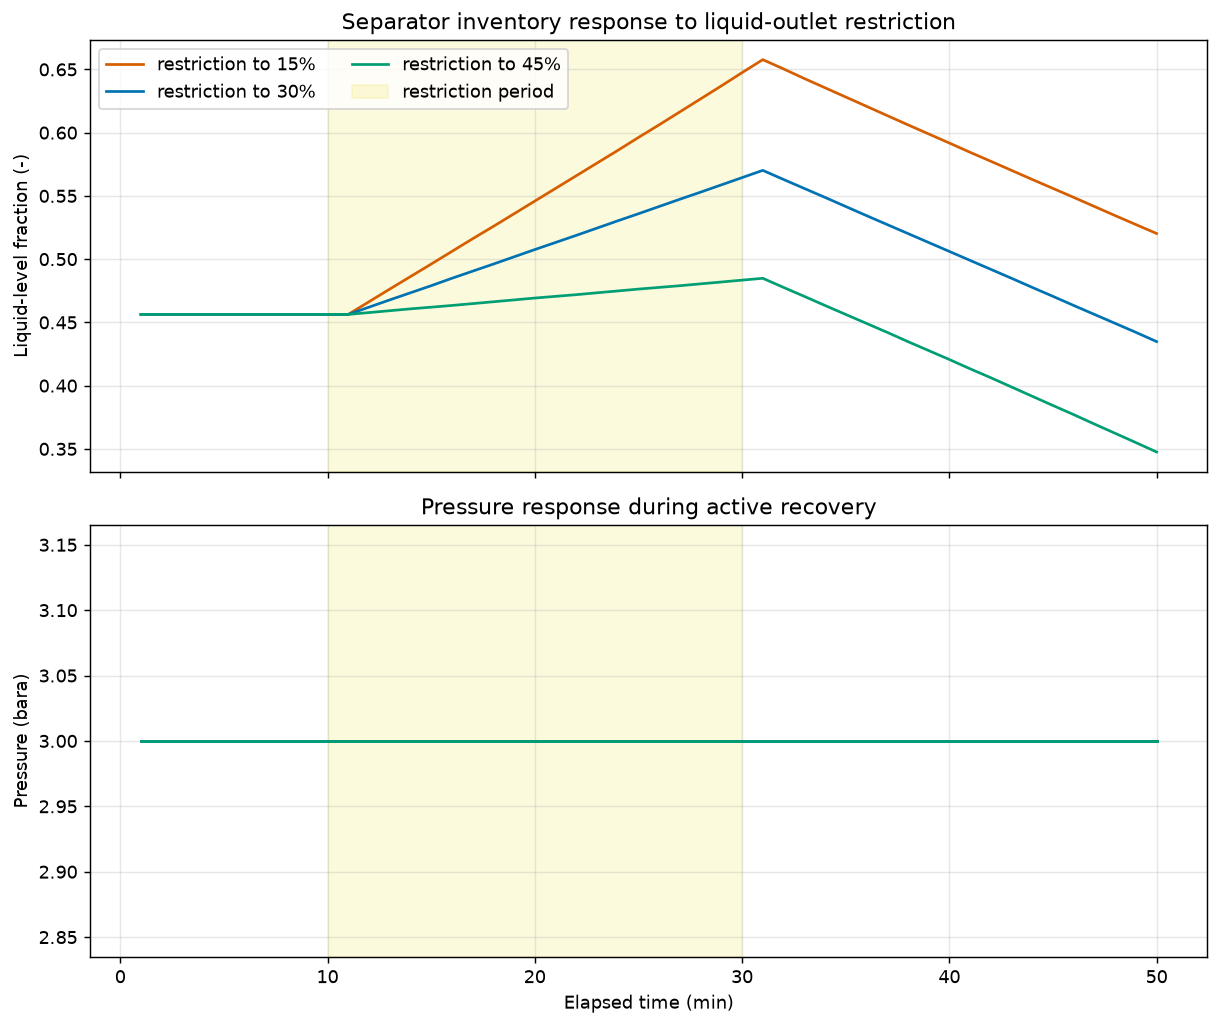

In [16]:
figure, axes = plt.subplots(2, 1, figsize=(9.5, 8.0), sharex=True)
case_colors = {
    15.0: "#D55E00",
    30.0: "#0072B2",
    45.0: "#009E73",
}

for opening, case_frame in scenario_results.groupby(
    "restricted_opening_percent"
):
    label = f"restriction to {opening:.0f}%"
    axes[0].plot(
        case_frame["time_min"],
        case_frame["liquid_level_fraction"],
        label=label,
        color=case_colors[opening],
    )
    axes[1].plot(
        case_frame["time_min"],
        case_frame["pressure_bara"],
        label=label,
        color=case_colors[opening],
    )

for axis in axes:
    axis.axvspan(
        10.0,
        30.0,
        color="#F0E442",
        alpha=0.18,
        label="restriction period",
    )
    axis.grid(alpha=0.3)

axes[0].set_ylabel("Liquid-level fraction (-)")
axes[0].set_title("Separator inventory response to liquid-outlet restriction")
axes[0].legend(ncol=2)
axes[1].set_xlabel("Elapsed time (min)")
axes[1].set_ylabel("Pressure (bara)")
axes[1].set_title("Pressure response during active recovery")
figure.tight_layout()
plt.show()

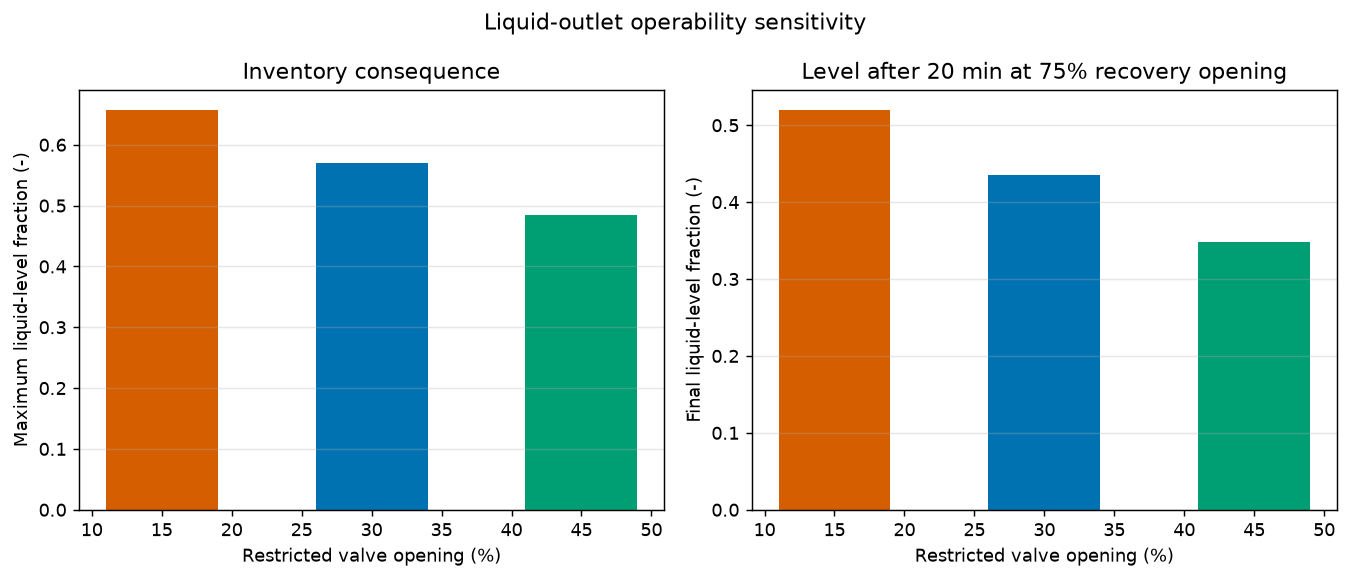

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
bar_colors = ["#D55E00", "#0072B2", "#009E73"]

axes[0].bar(
    scenario_summary["restricted_opening_percent"],
    scenario_summary["maximum_level_fraction"],
    color=bar_colors,
    width=8.0,
)
axes[0].set_xlabel("Restricted valve opening (%)")
axes[0].set_ylabel("Maximum liquid-level fraction (-)")
axes[0].set_title("Inventory consequence")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    scenario_summary["restricted_opening_percent"],
    scenario_summary["final_level_fraction"],
    color=bar_colors,
    width=8.0,
)
axes[1].set_xlabel("Restricted valve opening (%)")
axes[1].set_ylabel("Final liquid-level fraction (-)")
axes[1].set_title("Level after 20 min at 75% recovery opening")
axes[1].grid(axis="y", alpha=0.3)

figure.suptitle("Liquid-outlet operability sensitivity")
figure.tight_layout()
plt.show()

## 8. Numerical and physical validation

The checks below cover JSON-independent engineering behavior:

- finite thermodynamic and dynamic results;
- steady-state mass closure;
- isenthalpic PH-flash closure;
- complete and bounded state histories;
- physically bounded hydrogen depressurization;
- valid stream-quality states; and
- the expected increase in liquid inventory as the outlet restriction becomes more
  severe.

An assertion failure is a prompt to inspect API compatibility, units, phase existence,
or the selected operating range rather than suppressing the result.

In [18]:
engineering_checks = []


def check(condition, description):
    assert condition, description
    engineering_checks.append(description)


check(NEQSIM_VERSION == "3.16.0", "tested NeqSim version was recorded")
check(
    abs(mass_balance_residual) < 1.0e-6,
    "steady propane mass balance closed below 1e-6 kg/hr",
)
check(
    np.isfinite(base_case_table["value"]).all(),
    "base-case results were finite",
)
check(
    len(propane_time_min)
    == len(propane_liquid_level)
    == len(propane_temperature_c)
    == len(propane_pressure_bara)
    == 80,
    "all propane histories contain 80 synchronized points",
)
check(
    np.isfinite(propane_transient_table.to_numpy()).all(),
    "all propane transient states were finite",
)
check(
    np.min(propane_liquid_level) >= 0.0
    and np.max(propane_liquid_level) <= 1.0,
    "propane liquid level remained between zero and one",
)
check(
    saturation_pressure_bara > 0.0,
    "phase-fraction pressure flash returned positive pressure",
)
check(
    np.isfinite(saturation_temperature_c),
    "phase-fraction temperature flash returned a finite result",
)
check(
    abs(ph_flash_enthalpy_j - initial_enthalpy_j)
    <= max(1.0e-5 * abs(initial_enthalpy_j), 1.0e-6),
    "PH flash preserved enthalpy within numerical tolerance",
)
check(
    np.isfinite(dew_point_temperature_c),
    "pure-propane dew temperature was finite",
)
check(
    len(hydrogen_time_s) == len(hydrogen_pressure_bara),
    "hydrogen time and pressure arrays were synchronized",
)
check(
    np.isfinite(hydrogen_pressure_bara).all(),
    "hydrogen pressure history was finite",
)
check(
    hydrogen_pressure_bara[-1] > 1.01325,
    "hydrogen calculation stopped above the downstream boundary",
)
check(
    hydrogen_pressure_bara[-1] < hydrogen_pressure_bara[49],
    "hydrogen vessel pressure decreased after inlet closure",
)
check(
    hydrogen_liquid_valve.getOutletStream().getFlowRate("kg/hr") == 0.0,
    "single-phase hydrogen nominal liquid outlet remained empty",
)
check(
    np.isfinite(quality_specification_table.iloc[:, 1:].to_numpy()).all(),
    "all stream-quality specification results were finite",
)
check(
    0.0 <= quality_specification_table["vapor_fraction"].min()
    and quality_specification_table["vapor_fraction"].max() <= 1.0,
    "all reported vapor fractions were bounded",
)
check(
    np.isfinite(scenario_results.iloc[:, 2:].to_numpy()).all(),
    "all scenario states were finite",
)
check(
    (
        scenario_results["liquid_level_fraction"].between(0.0, 1.0)
    ).all(),
    "all scenario liquid levels were physically bounded",
)

maximum_levels = scenario_summary["maximum_level_fraction"].to_numpy()
check(
    np.all(np.diff(maximum_levels) <= 0.0),
    "maximum liquid level decreased as restricted opening increased",
)
check(
    scenario_summary["final_level_fraction"].max()
    < scenario_summary["maximum_level_fraction"].max(),
    "the 75% recovery opening reduced the worst accumulated inventory",
)

print(f"All {len(engineering_checks)} engineering checks passed.")
for check_number, description in enumerate(engineering_checks, start=1):
    print(f"{check_number:02d}. {description}")

All 21 engineering checks passed.
01. tested NeqSim version was recorded
02. steady propane mass balance closed below 1e-6 kg/hr
03. base-case results were finite
04. all propane histories contain 80 synchronized points
05. all propane transient states were finite
06. propane liquid level remained between zero and one
07. phase-fraction pressure flash returned positive pressure
08. phase-fraction temperature flash returned a finite result
09. PH flash preserved enthalpy within numerical tolerance
10. pure-propane dew temperature was finite
11. hydrogen time and pressure arrays were synchronized
12. hydrogen pressure history was finite
13. hydrogen calculation stopped above the downstream boundary
14. hydrogen vessel pressure decreased after inlet closure
15. single-phase hydrogen nominal liquid outlet remained empty
16. all stream-quality specification results were finite
17. all reported vapor fractions were bounded
18. all scenario states were finite
19. all scenario liquid levels we

## 9. Engineering interpretation

- The propane separator responds slowly because vessel inventory integrates the
  difference between inlet and outlet flows.
- Restricting the liquid outlet increases inventory. Returning only to the nominal
  50% opening does not drain that inventory; a temporary 75% recovery opening reduces
  level, with the rate governed by valve capacity and available pressure drop.
- Pressure and temperature respond to flashing and changing vapor inventory, not only
  to valve opening.
- Pure-component phase-fraction flashes collapse to the saturation line.
- A single-phase hydrogen vessel has no meaningful liquid-specific properties. Phase
  existence must be checked before requesting mass-specific tables.
- The scenario threshold is illustrative. Project acceptance limits should come from
  separator geometry, alarms, trips, relief design, and operating philosophy.

## 10. Limitations and applicability

The examples use equilibrium SRK thermodynamics, lumped separator inventories,
idealized valve behavior, and deterministic synthetic inputs. They omit wall heat
transfer, detailed valve coefficients versus travel, level-controller dynamics,
compressor maps, check valves, relief devices, ignition hazards, and structural
design. Hydrogen predictions near cryogenic conditions require a model and validation
range chosen for that purpose.

Use this notebook for API learning, model debugging, and early operability screening.
Use validated project fluids, equipment data, safeguards, and independent review for
design decisions.

## 11. Troubleshooting

- **Empty-phase arithmetic error:** check outlet flow or phase existence before
  requesting `J/kg` properties.
- **History arrays differ in length:** append every state variable in one recorder
  function after each transient step.
- **Unexpected pressure below the outlet boundary:** stop the run at the boundary or
  add explicit non-return and vacuum-protection logic.
- **No dynamic response:** run the steady base case first, set equipment to
  non-steady calculation, configure a positive time step, and use `runTransient()`.
- **Colab import failure:** rerun only the setup cell, then restart from the import
  cell; do not install NeqSim repeatedly in later cells.

## 12. Summary and further exercises

This notebook preserves and repairs four pure-component NeqSim workflows, recalculates
all seven original plots, and adds a reusable liquid-outlet operability application.

Exercises:

1. add a PI level controller and compare it with fixed valve restoration;
2. vary separator diameter and quantify inventory response time;
3. add ambient heat transfer to the hydrogen vessel;
4. compare SRK and PR for propane saturation states; and
5. replace pure propane with a documented binary hydrocarbon mixture and discuss why
   bubble and dew conditions separate.

## 13. Authoritative references

- [NeqSim process simulation package](https://equinor.github.io/neqsim/process/README.html)
- [Process recipes: streams and flowsheets](https://equinor.github.io/neqsim/cookbook/process-recipes.html#streams)
- [Valves](https://equinor.github.io/neqsim/process/equipment/valves.html)
- [Separators](https://equinor.github.io/neqsim/process/equipment/separators.html)
- [Dynamic simulation guide](https://equinor.github.io/neqsim/simulation/dynamic_simulation_guide.html)
- [Thermodynamic operations](https://equinor.github.io/neqsim/thermo/thermodynamic_operations.html)

The notebook uses public synthetic inputs and contains no proprietary data.